# Registration pre-processing, step by step

Before `phase_cross_correlation` runs, each overlap strip in the stitching
pipeline is pushed through two filters (see `register_pcc`):

1. **Gaussian high-pass** &mdash; `img - gaussian_filter(img, sigma)`, which strips
   the smooth brightness envelope (residual vignette + tissue low-frequency
   gradient) so the true-texture correlation peak dominates.
2. **Separable Hann window** &mdash; tapers the image to zero at every edge so the
   hard borders don't leak a cross of energy through the FFT.

This notebook applies those same two steps to **one tile you choose** and shows
the raw image, the image after the high-pass, and the image after the Hann
window, side by side.

In [1]:
# -- Imports -------------------------------------------------------
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import tifffile
from scipy.ndimage import gaussian_filter

matplotlib.rcParams['figure.dpi'] = 120

In [2]:
# -- Helpers (same as the stitching pipeline) ----------------------

def load_tile(path):
    img = tifffile.imread(str(path)).astype('float32')
    while img.ndim > 2:
        img = img[0]
    return img


def norm_disp(img):
    lo, hi = img.min(), img.max()
    return (img - lo) / (hi - lo + 1e-9)


def highpass(img, sigma=12.0):
    """Subtract a large-sigma Gaussian to strip the smooth brightness envelope.
    High-pass, NOT band-pass."""
    img = img.astype('float32')
    return img - gaussian_filter(img, sigma)


def hann_window(shape):
    """Separable 2-D Hann window matching the one applied in register_pcc."""
    return np.hanning(shape[0])[:, None] * np.hanning(shape[1])[None, :]

In [3]:
# -- User input ----------------------------------------------------
# Pick ONE tile to inspect.
TILE_PATH = "/Users/spaltahill/Test Images Jul 13/260713_UltraII_5300149-5R_AFp80_cfos647p80_thickness3d5_width80_step40_ol20[00 x 00]_C00_z0048.ome.tif"

HIGHPASS_SIGMA = 12       # Gaussian sigma for the high-pass prefilter

Tile          : (2560, 2160)


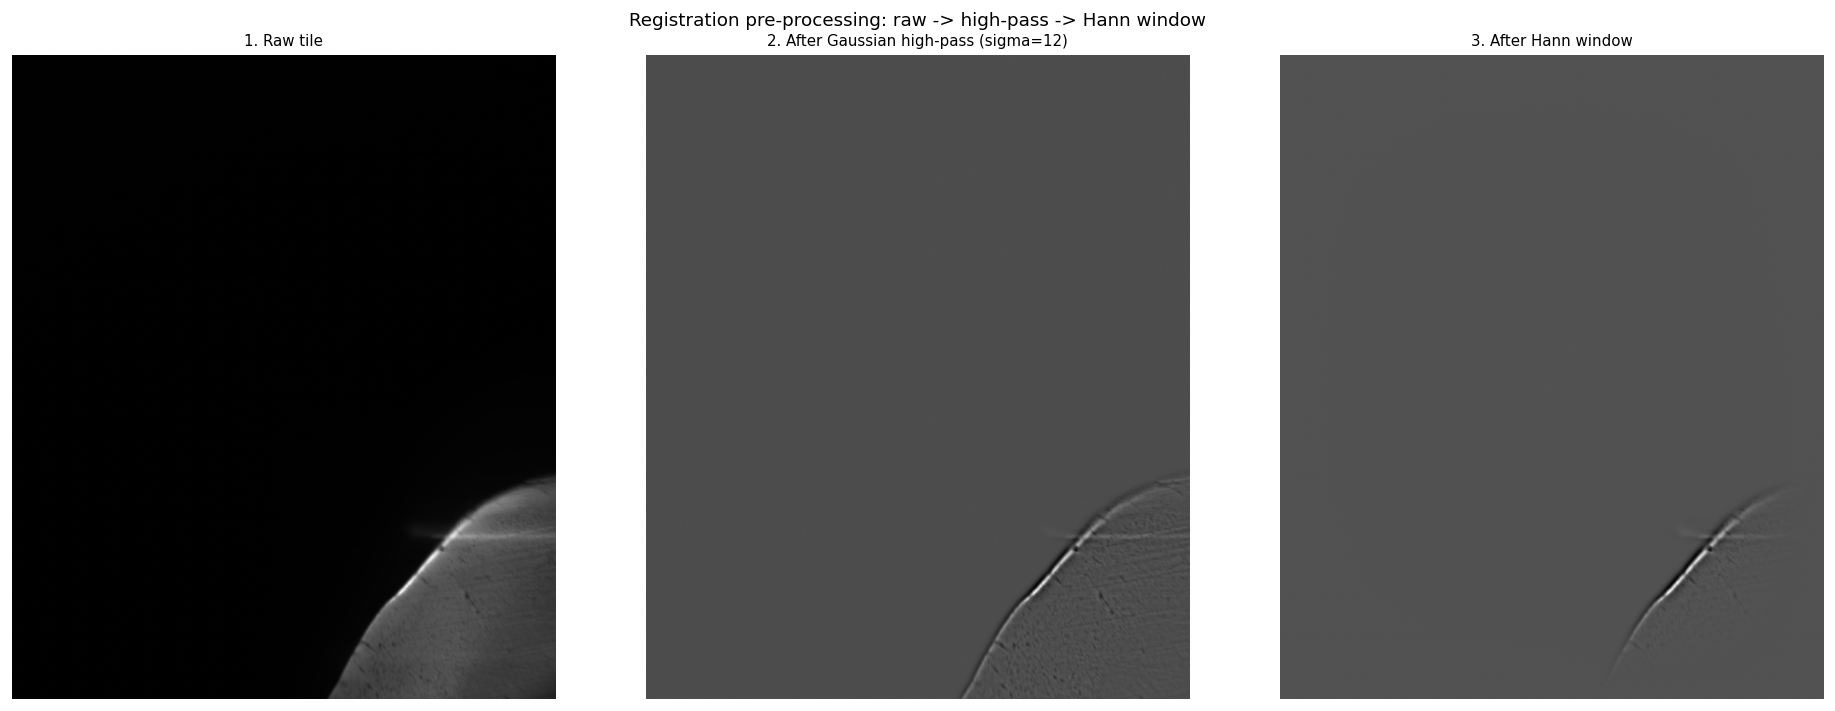

In [4]:
# -- Apply the two steps and plot all three side by side -----------
raw = load_tile(TILE_PATH)
print(f'Tile          : {raw.shape}')

after_hp   = highpass(raw, HIGHPASS_SIGMA)          # step 1: Gaussian high-pass
after_hann = after_hp * hann_window(after_hp.shape) # step 2: Hann window

panels = [
    (raw,        '1. Raw tile'),
    (after_hp,   f'2. After Gaussian high-pass (sigma={HIGHPASS_SIGMA})'),
    (after_hann, '3. After Hann window'),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, (img, title) in zip(axes, panels):
    ax.imshow(norm_disp(img), cmap='gray')
    ax.set_title(title, fontsize=9)
    ax.axis('off')
fig.suptitle('Registration pre-processing: raw -> high-pass -> Hann window', fontsize=11)
plt.tight_layout()
plt.show()